# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "../../"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /home/oana-vesa/ML_projects/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cpu
   Seed     : 42


{'in_colab': False,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'

df = pd.read_csv(data_path)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
# df = df.drop(columns=['year', 'month', 'day'])
# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# # Quick sanity check
# df[["date", "latitude", "CYCLE"]].head()

df.head(10)


,year,month,day,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,date
0,1825,11,5,12.0,30.0,0.0,-1.20,331.80,2120.0,570.0,101.0,NaN,1.0,1825-11-05
3,1825,11,8,12.0,0.0,0.0,-17.90,321.80,670.0,190.0,102.0,NaN,1.0,1825-11-08
4,1825,11,9,14.0,45.0,0.0,-14.60,320.70,500.0,150.0,102.0,NaN,1.0,1825-11-09
5,1825,11,10,12.0,0.0,0.0,-27.40,318.10,520.0,150.0,103.0,NaN,1.0,1825-11-10
6,1825,11,11,12.0,0.0,0.0,-26.30,320.80,470.0,140.0,103.0,NaN,1.0,1825-11-11
9,1825,11,14,12.0,0.0,0.0,-12.40,324.50,630.0,180.0,104.0,NaN,1.0,1825-11-14
11,1825,11,16,10.0,30.0,0.0,14.90,324.50,380.0,120.0,105.0,NaN,1.0,1825-11-16
13,1825,11,18,11.0,0.0,0.0,-30.70,189.70,276.0,88.0,106.0,NaN,1.0,1825-11-18
20,1825,11,25,14.0,30.0,0.0,39.88,113.82,185.0,63.0,107.0,NaN,1.0,1825-11-25
21,1825,11,25,14.0,30.0,0.0,34.89,120.08,20.0,13.0,108.0,NaN,1.0,1825-11-25


# Define Global Plotting Commands

In [3]:
import matplotlib.pyplot as plt

# Label sizes
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.title_fontsize'] = 16
#Axes tick marks
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

# Plotting choices
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.markerscale'] = 3


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

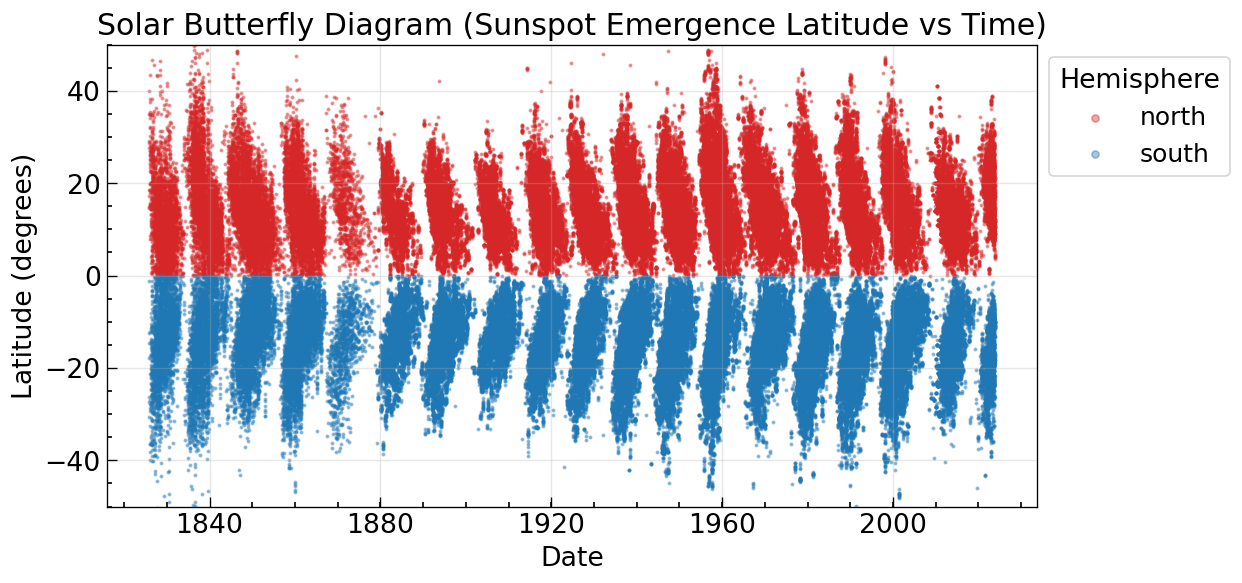

In [4]:

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", bbox_to_anchor=(1.0, 1), loc='upper left', fancybox=True, frameon=True)
ax.set_ylim(-50, 50)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


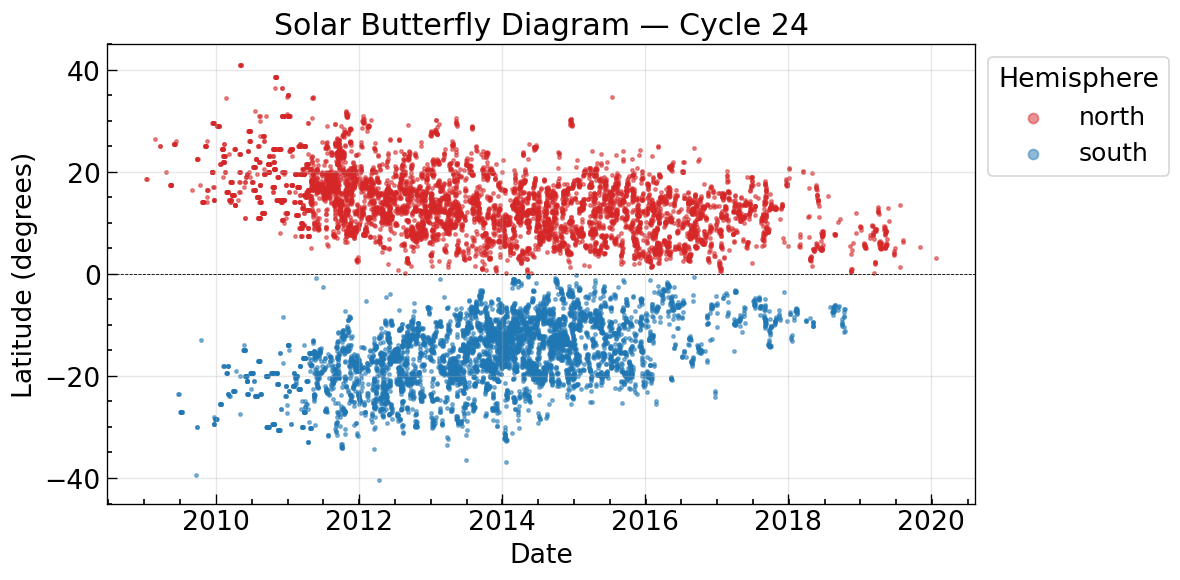

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [5]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", bbox_to_anchor=(1.0, 1), loc='upper left', fancybox=True, frameon=True)
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_17800/3864515172.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


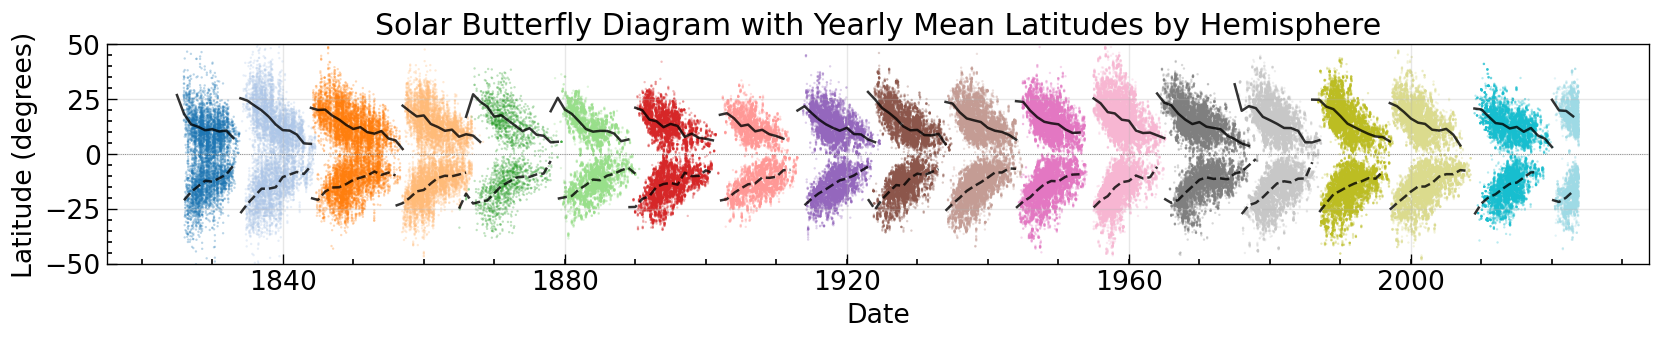

In [6]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]
    
    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
                linewidth=1.5, linestyle="-", alpha=0.8)
    
    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-50, 50)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

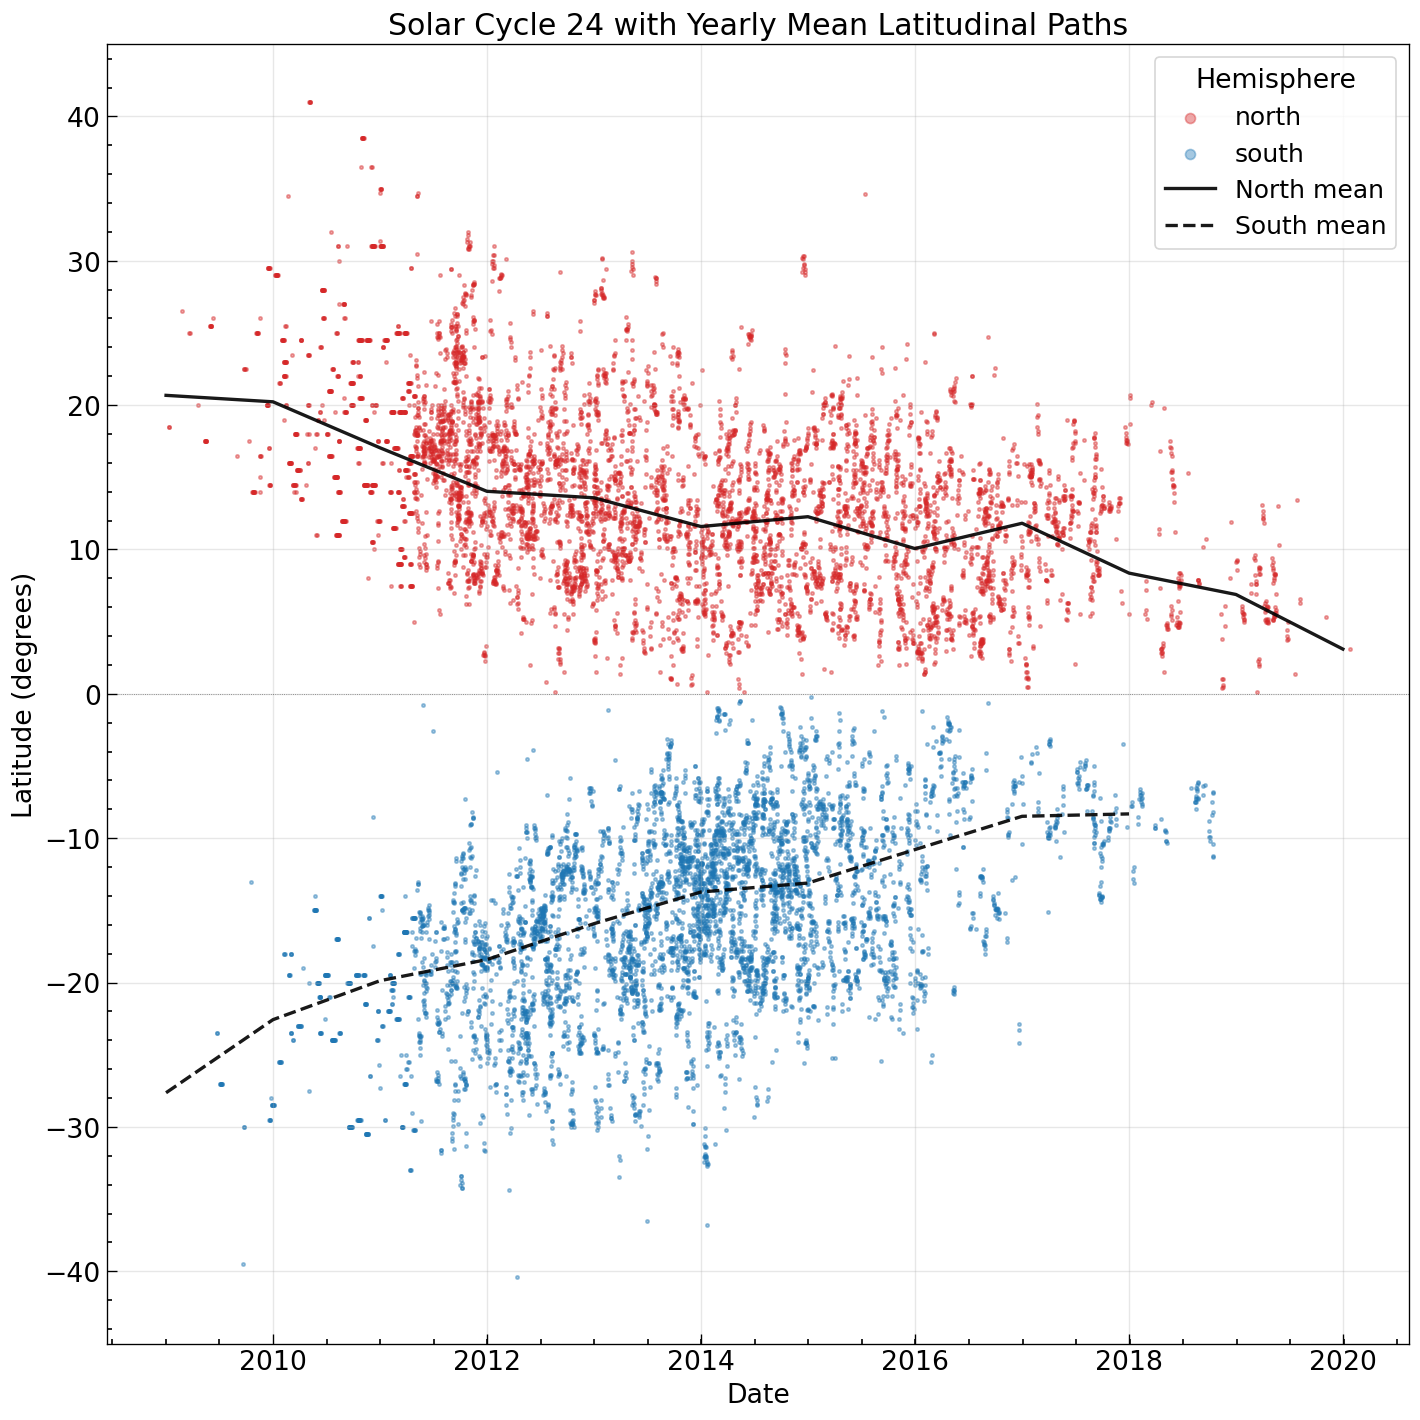

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [7]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


------------------------------------------------

## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


In [8]:
# Put your code for Task 6 here

year_selection = 2020
hemisphere_selection = 'north'

df['date'] = pd.to_datetime(df['date'])

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}


In [9]:
# Filter by year and hemisphere

df_filtered = df[
    (df['date'].dt.year == year_selection) &
    (df['hemisphere'] == hemisphere_selection)
]
df_filtered.head(10)

,year,month,day,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,date,hemisphere
308626,2020,1,9,6.0,0.0,0.0,22.9,16.9,40.1730,4.2899,324000.0,NaN,1002.0,2020-01-09,north
308627,2020,1,10,4.0,19.2,0.0,23.2,18.8,12.8100,3.6289,324000.0,NaN,1002.0,2020-01-10,north
308638,2020,1,20,6.0,0.0,0.0,16.3,156.5,2.2943,1.0191,324000.0,NaN,1002.0,2020-01-20,north
308642,2020,1,24,6.0,14.4,0.0,3.1,84.4,3.9933,1.3593,324000.0,24.0,1002.0,2020-01-24,north
308643,2020,1,25,6.0,14.4,0.0,3.0,87.0,8.9087,1.6472,324000.0,NaN,1002.0,2020-01-25,north
308644,2020,1,26,5.0,45.6,0.0,3.1,86.9,67.1320,3.7860,324000.0,NaN,1002.0,2020-01-26,north
308645,2020,1,27,6.0,28.8,0.0,3.0,87.7,87.1220,4.2263,324000.0,NaN,1002.0,2020-01-27,north
308646,2020,1,28,8.0,38.4,0.0,2.3,90.1,70.2070,3.9430,324000.0,NaN,1002.0,2020-01-28,north
308647,2020,1,29,12.0,28.8,0.0,2.1,91.5,52.5000,3.7563,324000.0,NaN,1002.0,2020-01-29,north
308648,2020,1,30,6.0,28.8,0.0,2.1,90.8,48.2730,3.9131,324000.0,NaN,1002.0,2020-01-30,north


# looking into https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html

In [36]:
df_filtered["latitude"].describe()

count    73.000000
mean     20.523288
std       9.466557
min       2.100000
25%      17.700000
50%      23.500000
75%      27.500000
max      34.400000
Name: latitude, dtype: float64

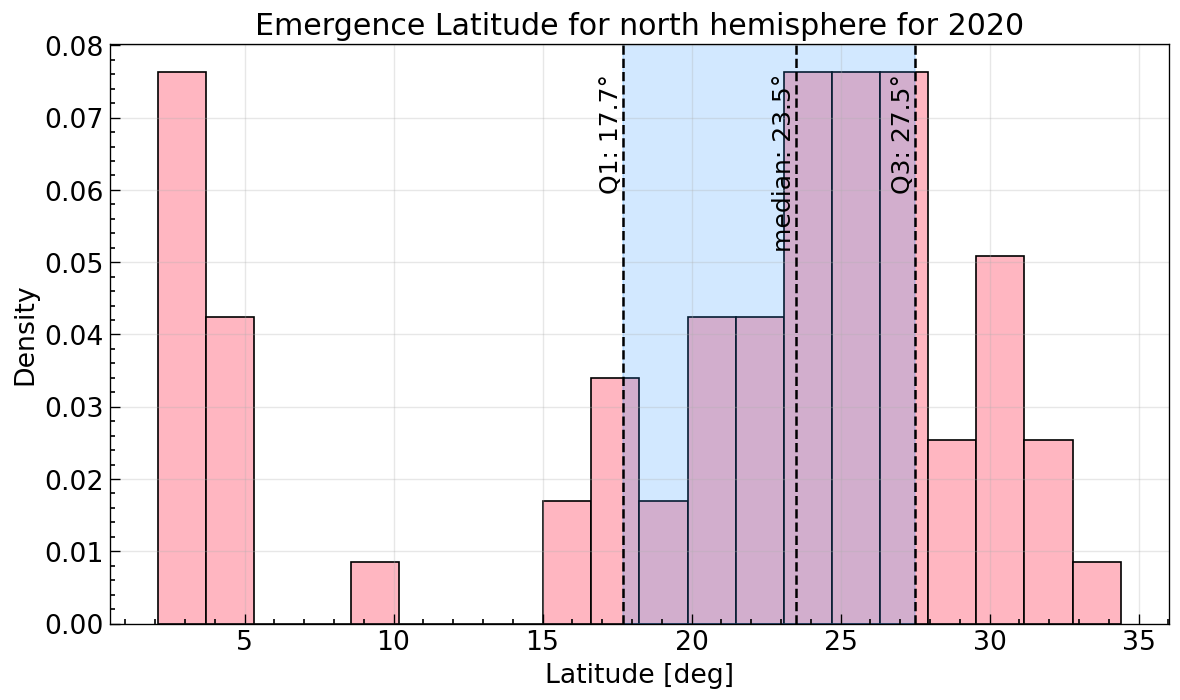

In [35]:
fig, axs = plt.subplots(1, 1, figsize=[10,6], tight_layout=True)


median_val = df_filtered["latitude"].quantile(0.50)
Q1_val = df_filtered["latitude"].quantile(0.25)
Q3_val = df_filtered["latitude"].quantile(0.75)
IQR_range = Q3_val - Q1_val

axs = df_filtered["latitude"].plot.hist(bins=20, density=True, color='lightpink',edgecolor='black')

axs.axvline(x=median_val, color='k', linestyle='--', linewidth=1.5)
axs.text(median_val, axs.get_ylim()[1] * 0.95, f'median: {median_val:.1f}°', 
         rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=15)

axs.axvline(x=Q1_val, color='k', linestyle='--', linewidth=1.5)
axs.text(Q1_val, axs.get_ylim()[1] * 0.95, f'Q1: {Q1_val:.1f}°', 
         rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=15)

axs.axvline(x=Q3_val, color='k', linestyle='--', linewidth=1.5)
axs.text(Q3_val, axs.get_ylim()[1] * 0.95, f'Q3: {Q3_val:.1f}°', 
         rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=15)

axs.axvspan(Q1_val, Q3_val, color='dodgerblue',alpha=0.2)
axs.set_xlabel("Latitude [deg]")
axs.set_ylabel("Density")
axs.set_title(f"Emergence Latitude for {hemisphere_selection} hemisphere for {year_selection}")
plt.show()

# What shape does the distribution have? Is it symmetric? 

### The histogram showing the emergence latitude for the northern hemisphere for the year 2020 is not symmetric. It appears skewed to the right; possible showing a bimodal distribution.

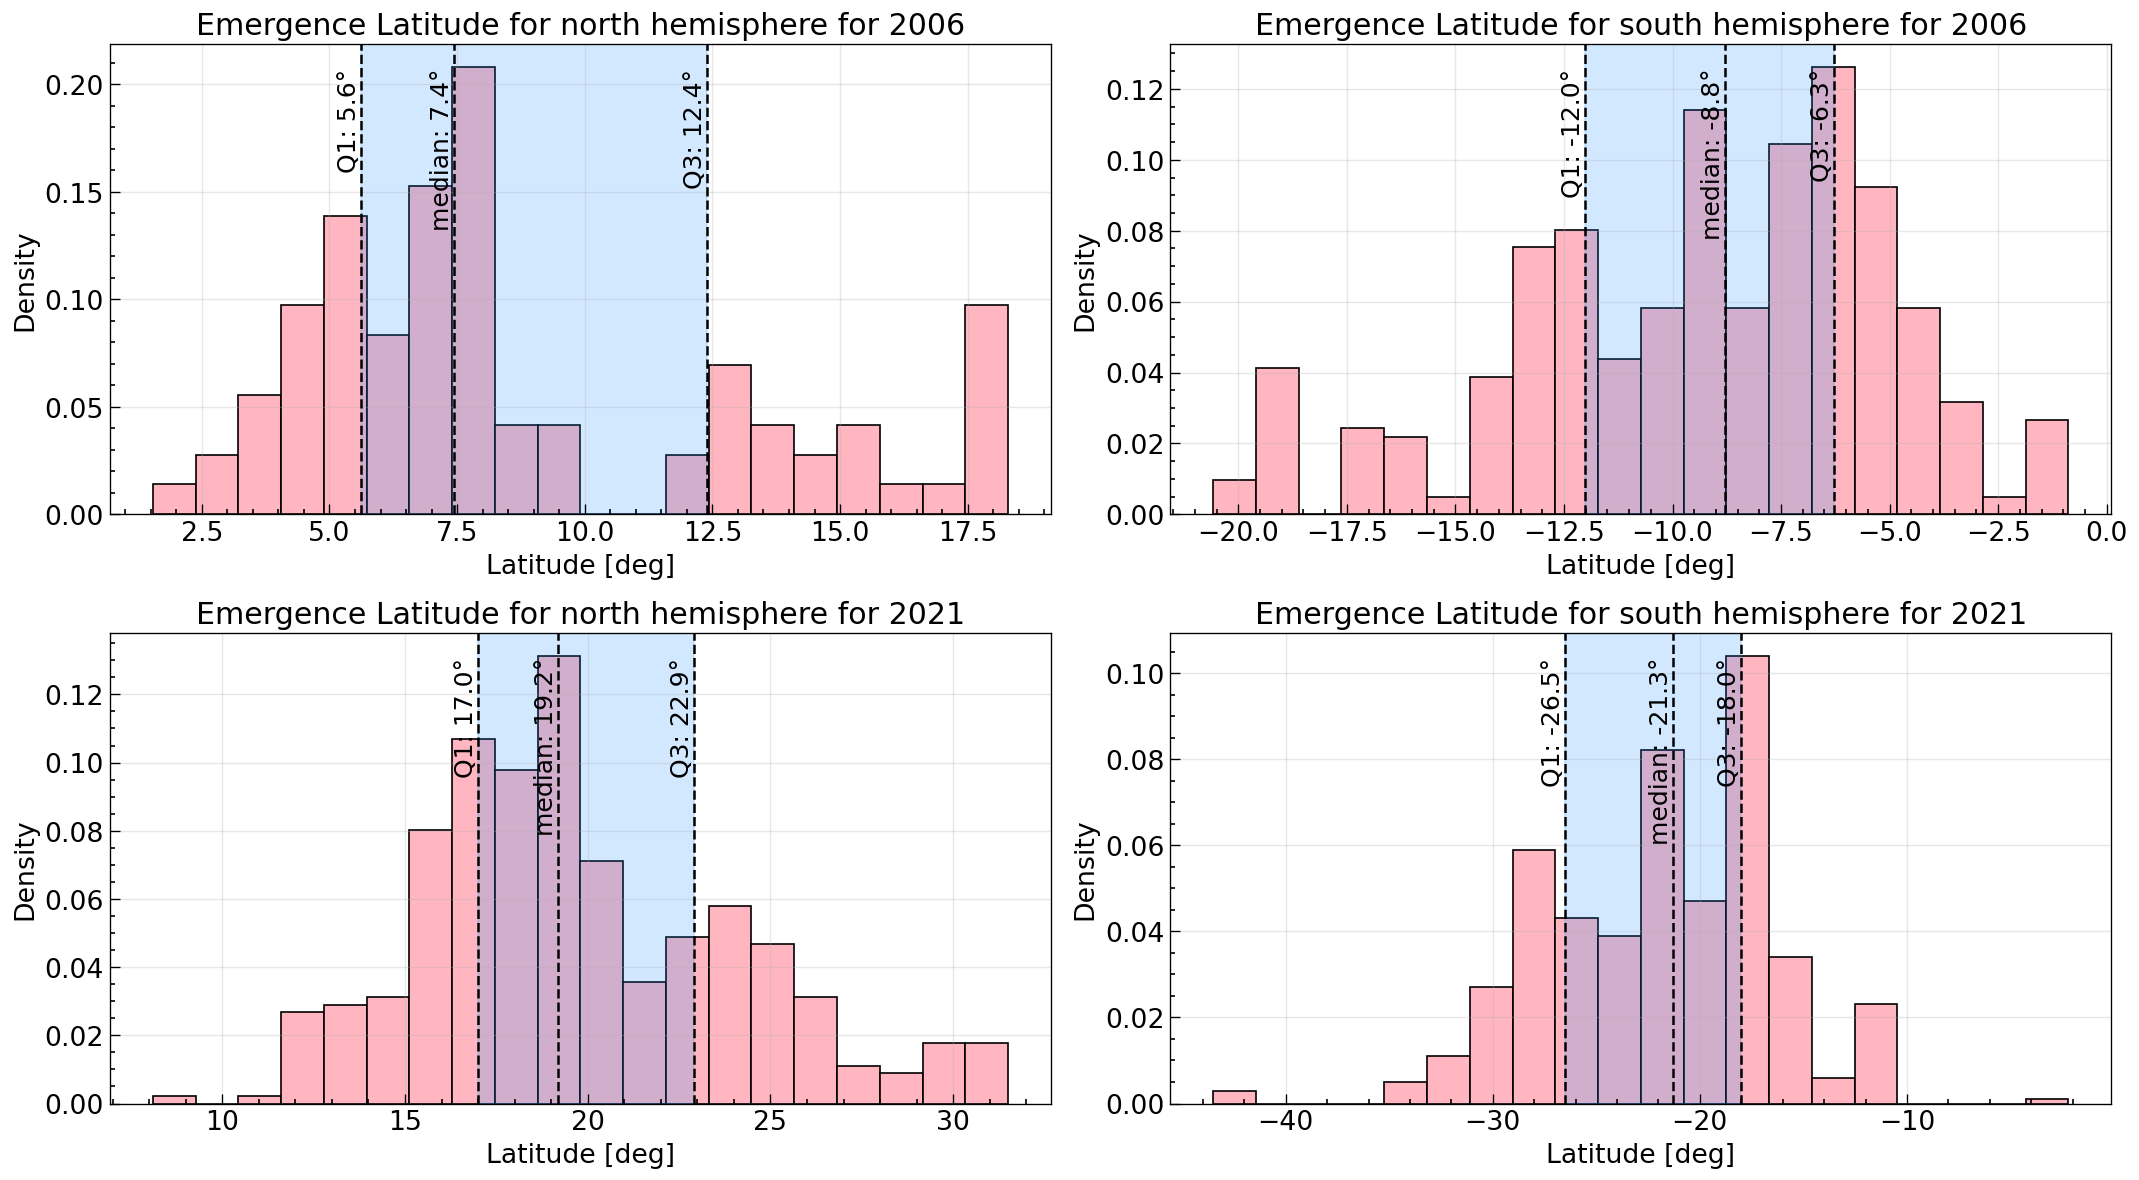

In [39]:
# Other hemispheres and years

combinations = [ ('north', 2006), ('south', 2006), ('north', 2021), ('south', 2021)]

n_cols = 2
n_rows = len(combinations) // n_cols + len(combinations) % n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=[18, 5 * n_rows], tight_layout=True)
axs = axs.flatten() 

for i, (hemisphere_selection, year_selection) in enumerate(combinations):
    ax = axs[i]
    
    # Filter data
    df_filtered = df[
        (df['date'].dt.year == year_selection) &
        (df['hemisphere'] == hemisphere_selection)
    ]

    if df_filtered.empty:
        ax.set_visible(False)
        continue

    # Stats
    median_val = df_filtered["latitude"].quantile(0.50)
    Q1_val     = df_filtered["latitude"].quantile(0.25)
    Q3_val     = df_filtered["latitude"].quantile(0.75)

    # Plot histogram onto the correct ax
    df_filtered["latitude"].plot.hist(
        bins=20, density=True,
        color='lightpink', edgecolor='black', ax=ax
    )
    
    for val, label in [(median_val, f'median: {median_val:.1f}°'),
                       (Q1_val,     f'Q1: {Q1_val:.1f}°'),
                       (Q3_val,     f'Q3: {Q3_val:.1f}°')]:
        ax.axvline(x=val, color='k', linestyle='--', linewidth=1.5)
        ax.text(val, ax.get_ylim()[1] * 0.95, label,
                rotation=90, verticalalignment='top',
                horizontalalignment='right', fontsize=15)
        
    ax.axvspan(Q1_val, Q3_val, color='dodgerblue', alpha=0.2)
    
    ax.set_xlabel("Latitude [deg]")
    ax.set_ylabel("Density")
    ax.set_title(f"Emergence Latitude for {hemisphere_selection} hemisphere for {year_selection}")

plt.show()

# Try switching to the other hemisphere and try different years — does the shape change?

### Yes, the shape changes. Even for the same year, the northern and southern hemisphere do not have the same shapes.

----------------------------------------

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


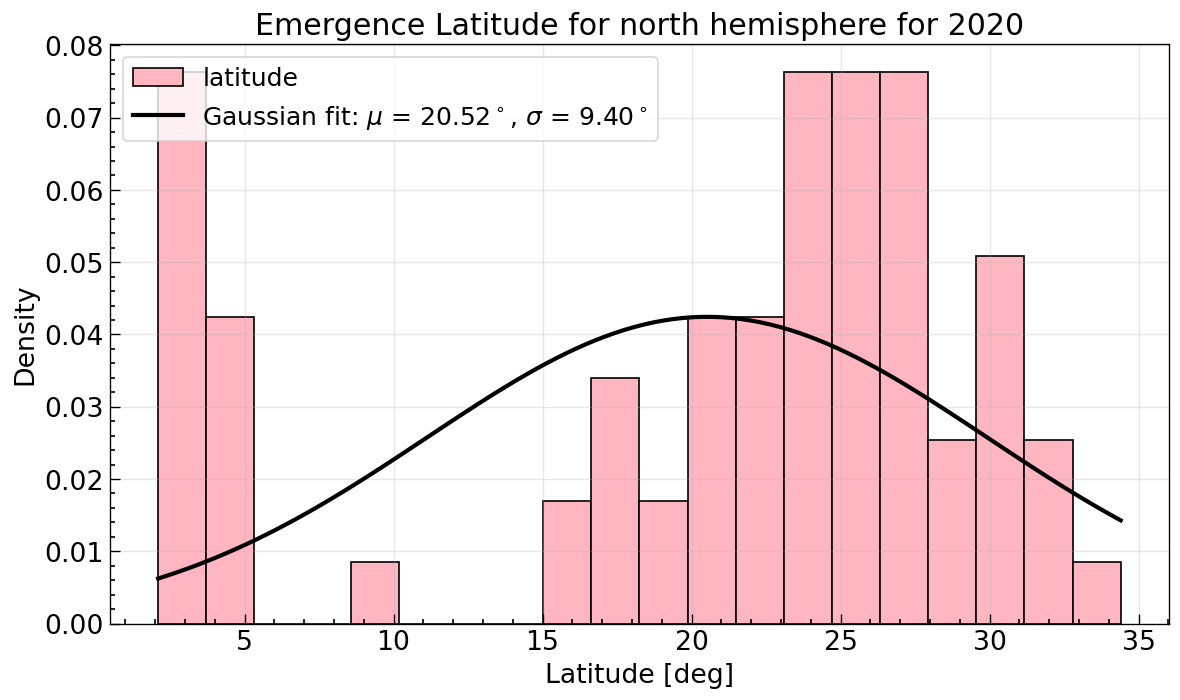

In [51]:
# Put your code for Task 7 here
from scipy.stats import norm

year_selection = 2020
hemisphere_selection = 'north'

df_filtered = df[
    (df['date'].dt.year == year_selection) &
    (df['hemisphere'] == hemisphere_selection)
]


fig, axs = plt.subplots(1, 1, figsize=[10,6], tight_layout=True)
axs = df_filtered["latitude"].plot.hist(bins=20, density=True, color='lightpink',edgecolor='black')
mu, sigma = norm.fit(df_filtered["latitude"].dropna())

x = np.linspace(df_filtered["latitude"].min(), df_filtered["latitude"].max(), 100)
eval_PDF = norm.pdf(x, mu, sigma)
axs.plot(x, eval_PDF, color='k',linewidth=2.5, label=rf'Gaussian fit: $\mu$ = {mu:.2f}$^\circ$, $\sigma$ = {sigma:.2f}$^\circ$')


axs.set_xlabel("Latitude [deg]")
axs.set_ylabel("Density")
axs.set_title(f"Emergence Latitude for {hemisphere_selection} hemisphere for {year_selection}")
axs.legend(loc='best', frameon=True)
plt.show()


# Does it fit well? Where does it agree with the data and where does it fail?

### For the northern hemisphere in the year 2020, it does not fit that well. The empircal distribution is right skewed and bimodal so it does not completely fit under the gaussian distribution. The Gaussian is slightly right skewed but not that much. It fails at the low latitude, where there is a noticable cluster of sunspots.


# The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

###  The $\mu$ parameter refers to the mean latitude where the sunspots emerge for a particular hemisphere during a particular year. The $\sigma$ parameter is the spread in latitudes where the sunspots emerge for a particular hemisphere during a particular year.

------------------------------

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


In [ ]:
# Put your code for Task 8 here